In [2]:
!pip install pandas h3 pyarrow tqdm

In [4]:
import pandas as pd
import numpy as np
import h3
from tqdm import tqdm
from collections import defaultdict
from datetime import datetime


In [7]:
df = pd.read_csv('../chicago crimes.csv')
df.head()

/var/folders/dh/t016p6ms66zc3_d2crms5hlw0000gn/T/ipykernel_28624/2260344088.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../chicago crimes.csv')


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13311263,JG503434,07/29/2022 03:39:00 AM,023XX S TROY ST,1582,OFFENSE INVOLVING CHILDREN,CHILD PORNOGRAPHY,RESIDENCE,True,False,...,25.0,30.0,17,NaN,NaN,2022,04/18/2024 03:40:59 PM,NaN,NaN,NaN
1,13053066,JG103252,01/03/2023 04:44:00 PM,039XX W WASHINGTON BLVD,2017,NARCOTICS,MANUFACTURE / DELIVER - CRACK,SIDEWALK,True,False,...,28.0,26.0,18,NaN,NaN,2023,01/20/2024 03:41:12 PM,NaN,NaN,NaN
2,12131221,JD327000,08/10/2020 09:45:00 AM,015XX N DAMEN AVE,0326,ROBBERY,AGGRAVATED VEHICULAR HIJACKING,STREET,True,False,...,1.0,24.0,03,1162795.0,1909900.0,2020,05/17/2025 03:40:52 PM,41.908418,-87.677407,"(41.908417822, -87.67740693)"
3,11227634,JB147599,08/26/2017 10:00:00 AM,001XX W RANDOLPH ST,0281,CRIM SEXUAL ASSAULT,NON-AGGRAVATED,HOTEL/MOTEL,False,False,...,42.0,32.0,02,NaN,NaN,2017,02/11/2018 03:57:41 PM,NaN,NaN,NaN
4,13203321,JG415333,09/06/2023 05:00:00 PM,002XX N Wells st,1320,CRIMINAL DAMAGE,TO VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,...,42.0,32.0,14,1174694.0,1901831.0,2023,11/04/2023 03:40:18 PM,41.886018,-87.633938,"(41.886018055, -87.633937881)"


In [8]:
df.columns = (
    df.columns.str.strip()
      .str.lower()
      .str.replace(r"[^a-z0-9]+", "_", regex=True)
      .str.strip("_")
)

In [9]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["updated_on"] = pd.to_datetime(df["updated_on"], errors="coerce")

df.head()

/var/folders/dh/t016p6ms66zc3_d2crms5hlw0000gn/T/ipykernel_28624/3367665329.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["updated_on"] = pd.to_datetime(df["updated_on"], errors="coerce")


,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,13311263,JG503434,2022-07-29 03:39:00,023XX S TROY ST,1582,OFFENSE INVOLVING CHILDREN,CHILD PORNOGRAPHY,RESIDENCE,True,False,...,25.0,30.0,17,NaN,NaN,2022,2024-04-18 15:40:59,NaN,NaN,NaN
1,13053066,JG103252,2023-01-03 16:44:00,039XX W WASHINGTON BLVD,2017,NARCOTICS,MANUFACTURE / DELIVER - CRACK,SIDEWALK,True,False,...,28.0,26.0,18,NaN,NaN,2023,2024-01-20 15:41:12,NaN,NaN,NaN
2,12131221,JD327000,2020-08-10 09:45:00,015XX N DAMEN AVE,0326,ROBBERY,AGGRAVATED VEHICULAR HIJACKING,STREET,True,False,...,1.0,24.0,03,1162795.0,1909900.0,2020,2025-05-17 15:40:52,41.908418,-87.677407,"(41.908417822, -87.67740693)"
3,11227634,JB147599,2017-08-26 10:00:00,001XX W RANDOLPH ST,0281,CRIM SEXUAL ASSAULT,NON-AGGRAVATED,HOTEL/MOTEL,False,False,...,42.0,32.0,02,NaN,NaN,2017,2018-02-11 15:57:41,NaN,NaN,NaN
4,13203321,JG415333,2023-09-06 17:00:00,002XX N Wells st,1320,CRIMINAL DAMAGE,TO VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,...,42.0,32.0,14,1174694.0,1901831.0,2023,2023-11-04 15:40:18,41.886018,-87.633938,"(41.886018055, -87.633937881)"


In [10]:
def to_bool(s):
    # handles True/False, "True"/"False", 1/0, "Y"/"N"
    if s.dtype == bool:
        return s
    return (
        s.astype(str)
         .str.strip()
         .str.lower()
         .map({"true": True, "false": False, "1": True, "0": False, "y": True, "n": False})
    )

for col in ["arrest", "domestic"]:
    if col in df.columns:
        df[col] = to_bool(df[col])

# numeric columns (safe coercion)
num_cols = ["ward", "community_area", "x_coordinate", "y_coordinate", "year", "latitude", "longitude"]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [11]:
before = len(df)

df_clean = df.dropna(subset=["date"])  # must have time
df_clean = df_clean.dropna(subset=["latitude", "longitude"])  # must have coords

# optional: keep only chicago-ish bounds to remove bad points
df_clean = df_clean[
    (df_clean["latitude"].between(41.60, 42.10)) &
    (df_clean["longitude"].between(-88.10, -87.40))
]

after = len(df_clean)
print(f"Rows before: {before:,} | after clean: {after:,} | dropped: {before-after:,} ({(before-after)/before:.1%})")
df_clean.head()

Rows before: 8,500,901 | after clean: 8,406,081 | dropped: 94,820 (1.1%)


,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
2,12131221,JD327000,2020-08-10 09:45:00,015XX N DAMEN AVE,0326,ROBBERY,AGGRAVATED VEHICULAR HIJACKING,STREET,True,False,...,1.0,24.0,03,1162795.0,1909900.0,2020,2025-05-17 15:40:52,41.908418,-87.677407,"(41.908417822, -87.67740693)"
4,13203321,JG415333,2023-09-06 17:00:00,002XX N Wells st,1320,CRIMINAL DAMAGE,TO VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,...,42.0,32.0,14,1174694.0,1901831.0,2023,2023-11-04 15:40:18,41.886018,-87.633938,"(41.886018055, -87.633937881)"
5,13204489,JG416325,2023-09-06 11:00:00,0000X E 8TH ST,0810,THEFT,OVER $500,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,...,4.0,32.0,06,1176857.0,1896680.0,2023,2023-11-04 15:40:18,41.871835,-87.626151,"(41.871834768, -87.62615082)"
6,11695116,JC272771,2019-05-21 08:20:00,018XX S CALIFORNIA AVE,0620,BURGLARY,UNLAWFUL ENTRY,RESIDENCE,False,False,...,25.0,29.0,05,1157982.0,1890961.0,2019,2024-01-19 15:40:50,41.856547,-87.695605,"(41.856547057, -87.695604526)"
7,12419690,JE295655,2021-07-07 10:30:00,132XX S GREENWOOD AVE,1544,SEX OFFENSE,SEXUAL EXPLOITATION OF A CHILD,RESIDENCE,False,False,...,10.0,54.0,17,1186051.0,1817781.0,2021,2024-01-19 15:40:50,41.655116,-87.594883,"(41.65511579, -87.594883198)"


In [12]:
if "id" in df_clean.columns:
    df_clean = df_clean.drop_duplicates(subset=["id"])
elif "case_number" in df_clean.columns:
    df_clean = df_clean.drop_duplicates(subset=["case_number", "date"])

print("After dedupe:", len(df_clean))

After dedupe: 8406081


In [13]:
df_clean["hour"] = df_clean["date"].dt.hour
df_clean["dow"] = df_clean["date"].dt.dayofweek  # Mon=0
df_clean["hour_of_week"] = df_clean["dow"] * 24 + df_clean["hour"]

df_clean["is_weekend"] = df_clean["dow"].isin([5, 6])
df_clean["is_night"] = (df_clean["hour"] >= 20) | (df_clean["hour"] <= 5)

df_clean[["date", "hour", "dow", "hour_of_week", "is_weekend", "is_night"]].head()

,date,hour,dow,hour_of_week,is_weekend,is_night
2,2020-08-10 09:45:00,9,0,9,False,False
4,2023-09-06 17:00:00,17,2,65,False,False
5,2023-09-06 11:00:00,11,2,59,False,False
6,2019-05-21 08:20:00,8,1,32,False,False
7,2021-07-07 10:30:00,10,2,58,False,False


In [14]:
print("Date range:", df_clean["date"].min(), "→", df_clean["date"].max())
print("Unique primary types:", df_clean["primary_type"].nunique() if "primary_type" in df_clean.columns else "N/A")

# missingness check
df_clean.isna().mean().sort_values(ascending=False).head(10)

Date range: 2001-01-01 00:00:00 → 2026-02-16 00:00:00
Unique primary types: 34


ward                    0.072035
community_area          0.071906
location_description    0.001215
district                0.000006
x_coordinate            0.000000
is_weekend              0.000000
hour_of_week            0.000000
dow                     0.000000
hour                    0.000000
location                0.000000
dtype: float64

In [15]:
primary_types = sorted(df_clean["primary_type"].dropna().unique())

for pt in primary_types:
    print(pt)

print("\nTotal primary types:", len(primary_types))
df_clean["primary_type"].value_counts().sort_values(ascending=False)

ARSON
ASSAULT
BATTERY
BURGLARY
CONCEALED CARRY LICENSE VIOLATION
CRIM SEXUAL ASSAULT
CRIMINAL DAMAGE
CRIMINAL SEXUAL ASSAULT
CRIMINAL TRESPASS
DECEPTIVE PRACTICE
DOMESTIC VIOLENCE
GAMBLING
HOMICIDE
HUMAN TRAFFICKING
INTERFERENCE WITH PUBLIC OFFICER
INTIMIDATION
KIDNAPPING
LIQUOR LAW VIOLATION
MOTOR VEHICLE THEFT
NARCOTICS
NON-CRIMINAL
OBSCENITY
OFFENSE INVOLVING CHILDREN
OTHER NARCOTIC VIOLATION
OTHER OFFENSE
PROSTITUTION
PUBLIC INDECENCY
PUBLIC PEACE VIOLATION
RITUALISM
ROBBERY
SEX OFFENSE
STALKING
THEFT
WEAPONS VIOLATION

Total primary types: 34


primary_type
THEFT                                1784232
BATTERY                              1541831
CRIMINAL DAMAGE                       961721
NARCOTICS                             753109
ASSAULT                               568575
OTHER OFFENSE                         525992
BURGLARY                              447119
MOTOR VEHICLE THEFT                   433329
DECEPTIVE PRACTICE                    371147
ROBBERY                               314622
CRIMINAL TRESPASS                     227435
WEAPONS VIOLATION                     125780
PROSTITUTION                           69793
OFFENSE INVOLVING CHILDREN             56505
PUBLIC PEACE VIOLATION                 54850
SEX OFFENSE                            32529
CRIM SEXUAL ASSAULT                    25786
INTERFERENCE WITH PUBLIC OFFICER       20457
LIQUOR LAW VIOLATION                   15313
GAMBLING                               14568
ARSON                                  14430
HOMICIDE                               140

In [16]:
locations = sorted(df_clean["location_description"].dropna().unique())

for loc in locations:
    print(loc)

print("\nTotal unique location descriptions:", len(locations))
df_clean["location_description"].value_counts().sort_values(ascending=False)

ABANDONED BUILDING
AIRCRAFT
AIRPORT BUILDING NON-TERMINAL - NON-SECURE AREA
AIRPORT BUILDING NON-TERMINAL - SECURE AREA
AIRPORT EXTERIOR - NON-SECURE AREA
AIRPORT EXTERIOR - SECURE AREA
AIRPORT PARKING LOT
AIRPORT TERMINAL LOWER LEVEL - NON-SECURE AREA
AIRPORT TERMINAL LOWER LEVEL - SECURE AREA
AIRPORT TERMINAL MEZZANINE - NON-SECURE AREA
AIRPORT TERMINAL UPPER LEVEL - NON-SECURE AREA
AIRPORT TERMINAL UPPER LEVEL - SECURE AREA
AIRPORT TRANSPORTATION SYSTEM (ATS)
AIRPORT VENDING ESTABLISHMENT
AIRPORT/AIRCRAFT
ALLEY
ANIMAL HOSPITAL
APARTMENT
APPLIANCE STORE
ATHLETIC CLUB
ATM (AUTOMATIC TELLER MACHINE)
AUTO
AUTO / BOAT / RV DEALERSHIP
BANK
BANQUET HALL
BAR OR TAVERN
BARBER SHOP/BEAUTY SALON
BARBERSHOP
BASEMENT
BEACH
BOAT / WATERCRAFT
BOAT/WATERCRAFT
BOWLING ALLEY
BRIDGE
CAR WASH
CASINO/GAMBLING ESTABLISHMENT
CEMETARY
CHA APARTMENT
CHA BREEZEWAY
CHA ELEVATOR
CHA GROUNDS
CHA HALLWAY
CHA HALLWAY / STAIRWELL / ELEVATOR
CHA HALLWAY/STAIRWELL/ELEVATOR
CHA LOBBY
CHA PARKING LOT
CHA PARKING LOT /

location_description
STREET                    2205639
RESIDENCE                 1367723
APARTMENT                 1004185
SIDEWALK                   760847
OTHER                      265268
                           ...   
COUNTY JAIL                     1
FUNERAL PARLOR                  1
ROOF                            1
POLICE FACILITY                 1
JUNK YARD/GARBAGE DUMP          1
Name: count, Length: 218, dtype: int64

In [17]:
OUTDOOR_LOCATIONS = {
    "ALLEY",
    "BEACH",
    "BRIDGE",
    "CEMETARY",
    "CHA GROUNDS",
    "CHA PARKING LOT",
    "CHA PARKING LOT / GROUNDS",
    "CHA PARKING LOT/GROUNDS",
    "CHA PLAY LOT",
    "COLLEGE / UNIVERSITY - GROUNDS",
    "COLLEGE/UNIVERSITY GROUNDS",
    "CONSTRUCTION SITE",
    'CTA "L" PLATFORM',
    "CTA BUS STOP",
    "CTA PARKING LOT / GARAGE / OTHER PROPERTY",
    "CTA PLATFORM",
    "CTA TRACKS - RIGHT OF WAY",
    "DRIVEWAY",
    "DRIVEWAY - RESIDENTIAL",
    "DUMPSTER",
    "EXPRESSWAY EMBANKMENT",
    "FARM",
    "FOREST PRESERVE",
    "GANGWAY",
    "GAS STATION",
    "GAS STATION DRIVE/PROP.",
    "HIGHWAY / EXPRESSWAY",
    "HIGHWAY/EXPRESSWAY",
    "JUNK YARD/GARBAGE DUMP",
    "LAGOON",
    "LAKE",
    "LAKEFRONT / WATERFRONT / RIVERBANK",
    "LAKEFRONT/WATERFRONT/RIVERBANK",
    "LOADING DOCK",
    "PARK PROPERTY",
    "PARKING LOT",
    "PARKING LOT / GARAGE (NON RESIDENTIAL)",
    "PARKING LOT/GARAGE(NON.RESID.)",
    "PRAIRIE",
    "RAILROAD PROPERTY",
    "RIVER",
    "RIVER BANK",
    "ROOF",
    "SCHOOL - PRIVATE GROUNDS",
    "SCHOOL - PUBLIC GROUNDS",
    "SCHOOL YARD",
    "SCHOOL, PRIVATE, GROUNDS",
    "SCHOOL, PUBLIC, GROUNDS",
    "SIDEWALK",
    "STREET",
    "TRAILER",
    "TRUCK",
    "TRUCKING TERMINAL",
    "VACANT LOT",
    "VACANT LOT / LAND",
    "VACANT LOT/LAND",
    "WOODED AREA",
    "YARD",
}
df_clean["location_description"] = (
    df_clean["location_description"]
    .astype(str)
    .str.strip()
)
before_count = len(df_clean)

df_outdoor = df_clean[
    df_clean["location_description"].isin(OUTDOOR_LOCATIONS)
].copy()

after_count = len(df_outdoor)

print(f"Before filtering: {before_count:,}")
print(f"After filtering:  {after_count:,}")
print(f"Dropped rows:     {before_count - after_count:,}")
print(f"Percent removed:  {(before_count - after_count) / before_count:.2%}")


Before filtering: 8,406,081
After filtering:  3,794,108
Dropped rows:     4,611,973
Percent removed:  54.86%


In [18]:
primary_types = sorted(df_outdoor["primary_type"].dropna().unique())

print("\nTotal primary types:", len(primary_types))
df_outdoor["primary_type"].value_counts().sort_values(ascending=False)


Total primary types: 33


primary_type
THEFT                                717573
NARCOTICS                            618225
BATTERY                              595309
CRIMINAL DAMAGE                      458511
MOTOR VEHICLE THEFT                  396244
ROBBERY                              243073
ASSAULT                              235169
OTHER OFFENSE                        120538
WEAPONS VIOLATION                     90631
PROSTITUTION                          66147
CRIMINAL TRESPASS                     63541
DECEPTIVE PRACTICE                    59180
PUBLIC PEACE VIOLATION                32049
BURGLARY                              17682
INTERFERENCE WITH PUBLIC OFFICER      16836
GAMBLING                              12003
SEX OFFENSE                           10199
HOMICIDE                               9429
LIQUOR LAW VIOLATION                   7576
OFFENSE INVOLVING CHILDREN             5957
CRIM SEXUAL ASSAULT                    4816
KIDNAPPING                             4105
ARSON              

In [38]:
KEEP_TYPES = {
    "HOMICIDE",
    "CRIM SEXUAL ASSAULT",
    "CRIMINAL SEXUAL ASSAULT",
    "ROBBERY",
    "ASSAULT",
    "BATTERY",
    "WEAPONS VIOLATION",
    "KIDNAPPING",
    "STALKING",
    "HUMAN TRAFFICKING",
    "PUBLIC PEACE VIOLATION",
    "INTIMIDATION"
}
before = len(df_outdoor)

df_filtered = df_outdoor[
    df_outdoor["primary_type"].isin(KEEP_TYPES)
].copy()
df_filtered = df_filtered[df_filtered["domestic"] == False].copy()

after = len(df_filtered)

print(f"Before crime-type filter: {before:,}")
print(f"After crime-type filter:  {after:,}")
print(f"Dropped rows:             {before-after:,}")
print(f"Percent removed:          {(before-after)/before:.2%}")

Before crime-type filter: 3,794,108
After crime-type filter:  990,267
Dropped rows:             2,803,841
Percent removed:          73.90%


In [86]:
df_filtered.to_csv("../crime_clean_filtered.csv", index=False)
print("Saved to ../crime_clean_filtered.csv")

Saved to ../crime_clean_filtered.csv


In [40]:
SEVERITY_WEIGHTS = {
"HOMICIDE": 5,
"CRIM SEXUAL ASSAULT": 5,
"CRIMINAL SEXUAL ASSAULT": 5,
"KIDNAPPING": 5,
"ROBBERY": 4,
"WEAPONS VIOLATION": 2,
"ASSAULT": 3,
"BATTERY": 4,
"STALKING": 3,
"SEX OFFENSE": 4,
"HUMAN TRAFFICKING": 5,
"INTIMIDATION": 2,
"THEFT": 3,
"PUBLIC PEACE VIOLATION": 1,
"LIQUOR LAW VIOLATION": 2
}


In [58]:
H3_RESOLUTION = 9
LAMBDA = 0.01

df_filtered["severity"] = df_filtered["primary_type"].map(SEVERITY_WEIGHTS)
df_filtered[["primary_type", "severity"]].drop_duplicates().sort_values("severity")
# hour_of_week
df_filtered["hour_of_week"] = (
    df_filtered["date"].dt.dayofweek * 24 + df_filtered["date"].dt.hour
)

# h3 cell
df_filtered["h3"] = df_filtered.apply(
    lambda r: h3.latlng_to_cell(r["latitude"], r["longitude"], H3_RESOLUTION),
    axis=1
)

# recency decay
max_date = df_filtered["date"].max()
df_filtered["days_since"] = (max_date - df_filtered["date"]).dt.days
df_filtered["decay_weight"] = np.exp(-LAMBDA * df_filtered["days_since"] / 365)

# violent flag (based on your severity weights)
df_filtered["is_violent"] = df_filtered["severity"] >= 4

In [59]:
agg_df = (
    df_filtered
    .groupby(["h3", "hour_of_week"], as_index=False)
    .apply(lambda g: pd.Series({
        "sev_recent": (g["severity"] * g["decay_weight"]).sum(),
        "count_recent": g["decay_weight"].sum(),
        "violent_share": (
            (g["is_violent"].astype(int) * g["decay_weight"]).sum()
            / g["decay_weight"].sum()
        ) if g["decay_weight"].sum() > 0 else 0.0,
    }))
    .reset_index(drop=True)
)

In [60]:
print(agg_df.shape)
agg_df.head()

(382003, 5)


,h3,hour_of_week,sev_recent,count_recent,violent_share
0,8926641900bffff,64,3.189561,0.797390,1.0
1,89266419013ffff,63,2.440830,0.813610,0.0
2,89266419027ffff,5,2.676041,0.892014,0.0
3,89266419027ffff,36,2.903371,0.967790,0.0
4,89266419027ffff,53,2.685442,0.895147,0.0


In [61]:
agg_df["sev_recent"].describe()

count    382003.000000
mean          7.960581
std           7.882477
min           0.777969
25%           3.302584
50%           5.623949
75%           9.976918
max         430.072674
Name: sev_recent, dtype: float64

In [62]:
agg_df["risk"] = np.log1p(agg_df["sev_recent"])

In [63]:
agg_df["risk"].describe()

count    382003.000000
mean          1.959410
std           0.640247
min           0.575472
25%           1.459216
50%           1.890692
75%           2.395795
max           6.066277
Name: risk, dtype: float64

In [47]:
(agg_df["sev_recent"] > 0).mean()

1.0

In [50]:
agg_df["h3"].nunique()
agg_df["hour_of_week"].nunique()

168

In [87]:
agg_df[["h3", "hour_of_week", "risk"]].to_parquet("risk_table.parquet", index=False)

In [ ]:
risk_lookup = {
    (row.h3, row.hour_of_week): row.risk
    for row in agg_df.itertuples(index=False)
}

2.2281819142941113

In [84]:
H3_RESOLUTION = h3.get_resolution(agg_df["h3"].iloc[0])
LAMBDA_RISK = 0.5
GAMMA_SECL = 0.2

risk_lookup = {
    (row.h3, row.hour_of_week): row.risk
    for row in agg_df.itertuples(index=False)
}


FAST: {'length_km': 2.708975676915076, 'avg_risk': 1.731848474715885, 'total_cost': 5054.74337396898}
SAFE: {'length_km': 3.426885404014157, 'avg_risk': 0.5084348374459445, 'total_cost': 4298.0593656820665}


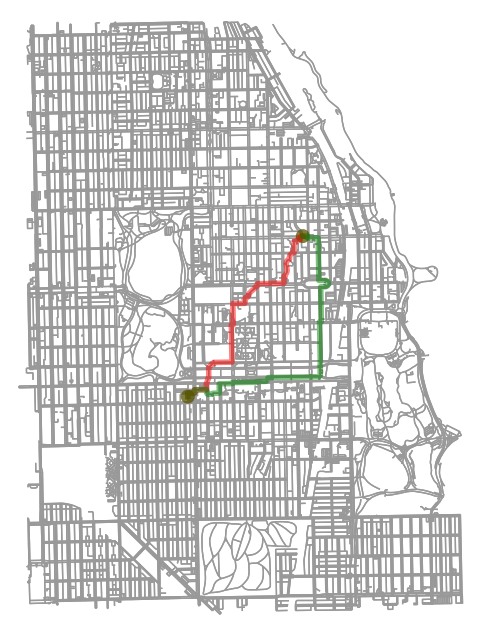

Text(0.5, 1.0, 'Fastest (red) vs Safest (green) — hour_of_week=118')

In [85]:
import numpy as np
import pandas as pd
import networkx as nx
import osmnx as ox
import h3
from shapely.geometry import box

# -----------------------------
# Option A routing (NO ML model)
# Use risk_lookup from agg_df:
#   risk_lookup[(h3_cell, hour_of_week)] -> risk (log1p(sev_recent))
# -----------------------------

# Pick a time bucket for routing (0..167). Example: Friday 10pm
# dayofweek: Mon=0 ... Sun=6
hour_of_week = 4 * 24 + 22  # Friday 22:00 = 118

# Choose origin/destination (lat, lon) — replace with your UI inputs later
ORIGIN = (41.79960573825807, -87.59240156626738)  # cafe 53
DEST   = (41.784529972951745, -87.60709202512507)  # Jewel-Osco

# Build a walking graph around the bounding box corridor
lat1, lon1 = ORIGIN
lat2, lon2 = DEST
buffer = 0.02  # ~2km-ish buffer; tune as needed

north = max(lat1, lat2) + buffer
south = min(lat1, lat2) - buffer
east  = max(lon1, lon2) + buffer
west  = min(lon1, lon2) - buffer

poly = box(west, south, east, north)
G = ox.graph_from_polygon(poly, network_type="walk", simplify=True)

# Default risk if we have no data for that (cell, hour)
DEFAULT_RISK = 0.0

def edge_midpoint_latlon(G, u, v, data):
    """Representative point for an edge: geometry midpoint else node midpoint."""
    geom = data.get("geometry", None)
    if geom is not None:
        mid = geom.interpolate(0.5, normalized=True)
        return float(mid.y), float(mid.x)
    uy, ux = G.nodes[u]["y"], G.nodes[u]["x"]
    vy, vx = G.nodes[v]["y"], G.nodes[v]["x"]
    return (uy + vy) / 2.0, (ux + vx) / 2.0

# Annotate edges with risk + cost
for u, v, k, data in G.edges(keys=True, data=True):
    length = float(data.get("length", 1.0))
    lat, lon = edge_midpoint_latlon(G, u, v, data)
    cell = h3.latlng_to_cell(lat, lon, H3_RESOLUTION)

    r = float(risk_lookup.get((cell, int(hour_of_week)), DEFAULT_RISK))
    data["risk"] = r

    # Risk-weighted cost: distance * (1 + lambda * risk)
    data["cost"] = length * (1.0 + float(LAMBDA_RISK) * r)

# Snap to nearest nodes
orig_node = ox.distance.nearest_nodes(G, X=lon1, Y=lat1)
dest_node = ox.distance.nearest_nodes(G, X=lon2, Y=lat2)

# Fastest (shortest) and Safest (min risk-weighted cost)
route_fast = nx.shortest_path(G, orig_node, dest_node, weight="length")
route_safe = nx.shortest_path(G, orig_node, dest_node, weight="cost")

def route_metrics(G, route):
    total_len = 0.0
    total_cost = 0.0
    risk_len = 0.0

    for a, b in zip(route[:-1], route[1:]):
        ed = G.get_edge_data(a, b)
        best_key = min(ed, key=lambda kk: float(ed[kk].get("cost", ed[kk].get("length", 1e18))))
        d = ed[best_key]

        L = float(d.get("length", 0.0))
        C = float(d.get("cost", L))
        R = float(d.get("risk", 0.0))

        total_len += L
        total_cost += C
        risk_len += R * L

    avg_risk = risk_len / max(total_len, 1e-9)
    return {
        "length_km": total_len / 1000.0,
        "avg_risk": avg_risk,
        "total_cost": total_cost
    }

m_fast = route_metrics(G, route_fast)
m_safe = route_metrics(G, route_safe)

print("FAST:", m_fast)
print("SAFE:", m_safe)

# Plot (overlap will blend colors if you use transparency; this uses solid colors)
fig, ax = ox.plot_graph_routes(
    G,
    routes=[route_fast, route_safe],
    route_colors=["red", "green"],
    route_linewidth=5,
    node_size=0,
    bgcolor="white"
)
ax.set_title(f"Fastest (red) vs Safest (green) — hour_of_week={hour_of_week}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.071916 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 354
[LightGBM] [Info] Number of data points in the train set: 5384885, number of used features: 15
[LightGBM] [Info] Start training from score -0.591754


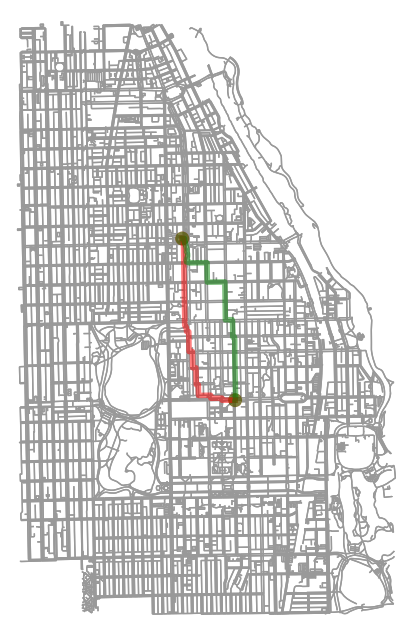

count    5153.000000
mean        0.295125
std         0.236931
min         0.194223
25%         0.194223
50%         0.194223
75%         0.194223
max         3.103032
dtype: float64
count    5153.000000
mean        0.246098
std         0.148131
min         0.177496
25%         0.177496
50%         0.177496
75%         0.177496
max         1.411726
dtype: float64
fraction zero sev preds: 0.0
fraction zero risk preds: 0.0


In [80]:
import numpy as np
import pandas as pd
import networkx as nx
import osmnx as ox
import h3

from lightgbm import LGBMRegressor

# -----------------------------
# A) Build weekly dataset for ML
# -----------------------------
# df must contain: date (datetime), severity (float), h3 (str)
# Example columns: df_filtered["date"], df_filtered["severity"], df_filtered["h3"]
df = df_filtered.copy()
df["date"] = pd.to_datetime(df["date"])
df["h3"] = df["h3"].astype(str)

H3_RESOLUTION = h3.get_resolution(df["h3"].iloc[0])

# Weekly bins (Monday-start weeks; change if you want)
# Week start = Monday 00:00 (consistent)
df["week"] = (df["date"] - pd.to_timedelta(df["date"].dt.weekday, unit="D")).dt.normalize()

cell_week = (
    df.groupby(["h3", "week"], as_index=False)
      .agg(sev_sum=("severity", "sum"),
           n_events=("severity", "size"),
           sev_mean=("severity", "mean"))
)

all_cells = cell_week["h3"].unique()
all_weeks = pd.date_range(cell_week["week"].min(), cell_week["week"].max(), freq="W-MON")

panel = (
    pd.MultiIndex.from_product([all_cells, all_weeks], names=["h3", "week"])
      .to_frame(index=False)
      .merge(cell_week, on=["h3", "week"], how="left")
)

for c in ["sev_sum", "n_events", "sev_mean"]:
    panel[c] = panel[c].fillna(0.0)

# Target: next week's severity sum (or risk)
panel = panel.sort_values(["h3", "week"])
panel["target_sev_next"] = panel.groupby("h3")["sev_sum"].shift(-1)

# Lag features
for lag in [1, 2, 3, 4]:
    panel[f"sev_sum_lag{lag}"] = panel.groupby("h3")["sev_sum"].shift(lag)
    panel[f"n_events_lag{lag}"] = panel.groupby("h3")["n_events"].shift(lag)

# Rolling features (past 4 weeks)
panel["sev_sum_roll4"] = (
    panel.groupby("h3")["sev_sum"]
         .rolling(4, min_periods=1)
         .mean()
         .reset_index(level=0, drop=True)
)
panel["n_events_roll4"] = (
    panel.groupby("h3")["n_events"]
         .rolling(4, min_periods=1)
         .mean()
         .reset_index(level=0, drop=True)
)

# Time features (seasonality)
panel["weekofyear"] = panel["week"].dt.isocalendar().week.astype(int)
panel["sin_woy"] = np.sin(2*np.pi*panel["weekofyear"]/52.0)
panel["cos_woy"] = np.cos(2*np.pi*panel["weekofyear"]/52.0)

# Drop rows where target is missing (last week per cell)
panel = panel.dropna(subset=["target_sev_next"])

# Define X/y
feature_cols = [
    "sev_sum", "n_events", "sev_mean",
    "sev_sum_lag1","sev_sum_lag2","sev_sum_lag3","sev_sum_lag4",
    "n_events_lag1","n_events_lag2","n_events_lag3","n_events_lag4",
    "sev_sum_roll4","n_events_roll4",
    "sin_woy","cos_woy"
]
panel = panel.dropna(subset=[c for c in feature_cols if "lag" in c])  # ensure lags exist

X = panel[feature_cols].astype(float)
y = panel["target_sev_next"].astype(float)  # predict log-risk

# Time split (no leakage): train on earlier weeks, test on later weeks
cutoff = panel["week"].quantile(0.8)   # last 20% weeks are “future”
train_mask = panel["week"] <= cutoff
test_mask  = panel["week"] > cutoff

model = LGBMRegressor(
    objective="tweedie",
    tweedie_variance_power=1.3,  # try 1.1–1.6
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
)
model.fit(X[train_mask], y[train_mask])

# -----------------------------
# B) Predict risk surface for a chosen week
# -----------------------------
# Choose an "as_of_week" where you want to route (use the last available week, or any in panel)
as_of_week = panel["week"].max()  # e.g. route "now"

# We need features for that week to predict next week risk
asof_rows = panel[panel["week"] == as_of_week].copy()
asof_pred_sev = model.predict(asof_rows[feature_cols].astype(float))
asof_pred_sev = np.clip(asof_pred_sev, 0, None)  # safety

# THIS is what you use for routing
asof_pred_risk = np.log1p(asof_pred_sev)

pred_risk_lookup = dict(zip(asof_rows["h3"].astype(str), asof_pred_risk.astype(float)))
baseline_pred = float(np.quantile(asof_pred_risk, 0.10))
# Optional smoothing of predictions across neighbors
def smooth_lookup(lookup: dict[str, float], k=1):
    out = {}
    for cell, r in lookup.items():
        neigh = h3.grid_disk(cell, k)
        vals = [lookup[n] for n in neigh if n in lookup]
        out[cell] = float(np.mean(vals)) if vals else float(r)
    return out

pred_risk_lookup = smooth_lookup(pred_risk_lookup, k=1)

# -----------------------------
# C) Routing using predicted risk
# -----------------------------
ORIGIN = (41.795, -87.598)   # (lat, lon) set yours
DEST   = (41.810, -87.605)

BBOX_BUFFER_DEG = 0.02
lat1, lon1 = ORIGIN
lat2, lon2 = DEST
north = max(lat1, lat2) + BBOX_BUFFER_DEG
south = min(lat1, lat2) - BBOX_BUFFER_DEG
east  = max(lon1, lon2) + BBOX_BUFFER_DEG
west  = min(lon1, lon2) - BBOX_BUFFER_DEG

G = ox.graph_from_bbox((west, south, east, north), network_type="walk", simplify=True)

LAMBDA_RISK = 2.0
GAMMA_SECL  = 0.2
SECLUDED_HIGHWAYS = {"service","path","track","footway","steps","pedestrian","cycleway"}
SECLUDED_SERVICE_VALUES = {"alley","driveway","parking_aisle"}

def _edge_highway_values(data):
    hw = data.get("highway", None)
    if hw is None: return set()
    if isinstance(hw, (list,tuple,set)): return set(map(str, hw))
    return {str(hw)}

def _midpoint_latlon(u, v, data):
    if "geometry" in data and data["geometry"] is not None:
        mid = data["geometry"].interpolate(0.5, normalized=True)
        return float(mid.y), float(mid.x)
    y1, x1 = G.nodes[u]["y"], G.nodes[u]["x"]
    y2, x2 = G.nodes[v]["y"], G.nodes[v]["x"]
    return float((y1+y2)/2), float((x1+x2)/2)

def seclusion_mult(data) -> float:
    highway_vals = _edge_highway_values(data)
    service = data.get("service", None)
    service_vals = set(service) if isinstance(service, (list,tuple,set)) else ({str(service)} if service else set())
    secluded = bool(highway_vals & SECLUDED_HIGHWAYS) or bool(service_vals & SECLUDED_SERVICE_VALUES)
    return GAMMA_SECL if secluded else 0.0

def edge_pred_risk(u, v, data) -> float:
    lat, lon = _midpoint_latlon(u, v, data)
    cell = h3.latlng_to_cell(lat, lon, H3_RESOLUTION)
    return float(pred_risk_lookup.get(cell, baseline_pred))

for u, v, k, data in G.edges(keys=True, data=True):
    length = float(data.get("length", 0.0))
    r = edge_pred_risk(u, v, data)
    secl = seclusion_mult(data)
    data["pred_risk"] = r
    data["cost"] = length * (1 + secl) * (1 + LAMBDA_RISK * r)

orig_node = ox.distance.nearest_nodes(G, X=lon1, Y=lat1)
dest_node = ox.distance.nearest_nodes(G, X=lon2, Y=lat2)

route_short = nx.shortest_path(G, orig_node, dest_node, weight="length")
route_safe  = nx.shortest_path(G, orig_node, dest_node, weight="cost")

fig, ax = ox.plot_graph_routes(G, [route_short, route_safe],
                               route_colors=["r","g"], route_linewidth=4,
                               node_size=0, bgcolor="w")

print(pd.Series(asof_pred_sev).describe())
print(pd.Series(asof_pred_risk).describe())
print("fraction zero sev preds:", np.mean(asof_pred_sev == 0))
print("fraction zero risk preds:", np.mean(asof_pred_risk == 0))

Shortest: {'length_km': 2.192300805229769, 'weighted_avg_pred_risk': 0.0, 'weighted_avg_seclusion': 0.0, 'total_cost': 2192.300805229769}
Safe:     {'length_km': 2.2069743570047042, 'weighted_avg_pred_risk': 0.22691269463106598, 'weighted_avg_seclusion': 0.0, 'total_cost': 3727.1100818544114}
Length ratio: 1.0066932200818115
Risk delta: -0.22691269463106598


In [82]:
def route_metrics(G, route, weight_attr="cost"):
    lengths = []
    risks = []
    secls = []
    costs = []

    for a, b in zip(route[:-1], route[1:]):
        ed = G.get_edge_data(a, b)

        # pick the edge with minimum weight_attr among parallel edges
        best_key = min(ed, key=lambda kk: float(ed[kk].get(weight_attr, ed[kk].get("length", 1e18))))
        d = ed[best_key]

        L = float(d.get("length", 0.0))
        r = float(d.get("pred_risk", baseline_pred))
        s = float(d.get("seclusion_mult", 0.0))
        c = float(d.get(weight_attr, 0.0))

        lengths.append(L)
        risks.append(r)
        secls.append(s)
        costs.append(c)

    total_len = float(np.sum(lengths))
    wavg_risk = float(np.average(risks, weights=np.maximum(lengths, 1e-6))) if total_len > 0 else float("nan")
    wavg_secl = float(np.average(secls, weights=np.maximum(lengths, 1e-6))) if total_len > 0 else float("nan")
    total_cost = float(np.sum(costs))

    return {
        "length_km": total_len / 1000.0,
        "weighted_avg_pred_risk": wavg_risk,
        "weighted_avg_seclusion": wavg_secl,
        "total_cost": total_cost,
    }

m_short = route_metrics(G, route_short, weight_attr="length")
m_safe  = route_metrics(G, route_safe,  weight_attr="cost")

route_safe  = nx.shortest_path(G, orig_node, dest_node, weight="cost")
m_safe  = route_metrics(G, route_safe, weight_attr="cost")

print("Shortest:", m_short)
print("Safe:    ", m_safe)
print("Length ratio:", m_safe["length_km"]/m_short["length_km"])
print("Risk delta:", m_short["weighted_avg_pred_risk"] - m_safe["weighted_avg_pred_risk"])

Shortest: {'length_km': 2.192300805229769, 'weighted_avg_pred_risk': 0.24906331441580806, 'weighted_avg_seclusion': 0.0, 'total_cost': 2192.300805229769}
Safe:     {'length_km': 2.2069743570047042, 'weighted_avg_pred_risk': 0.22691269463106598, 'weighted_avg_seclusion': 0.0, 'total_cost': 3727.1100818544114}
Length ratio: 1.0066932200818115
Risk delta: 0.022150619784742087


Routing using week: 2021-02-08 00:00:00


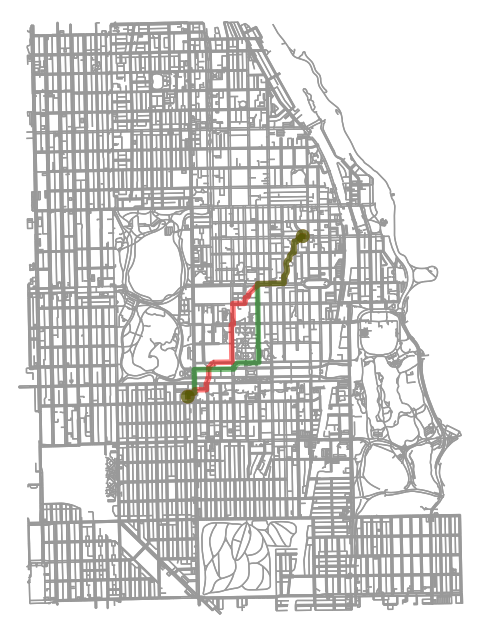

In [83]:
# ----------------------------------
# 1) Choose a test week
# ----------------------------------
test_weeks = sorted(panel.loc[test_mask, "week"].unique())
w = test_weeks[0]
print("Routing using week:", w)

pred_rows = panel[panel["week"] == w].copy()
pred_sev = np.clip(model.predict(pred_rows[feature_cols].astype(float)), 0, None)
pred_risk = np.log1p(pred_sev)

pred_lookup = dict(zip(pred_rows["h3"].astype(str), pred_risk.astype(float)))
pred_baseline = float(np.quantile(pred_risk, 0.10))

# ----------------------------------
# 2) Define origin/destination
# ----------------------------------
ORIGIN = (41.79960573825807, -87.59240156626738)  # cafe 53
DEST   = (41.784529972951745, -87.60709202512507)  # Jewel-Osco

lat1, lon1 = ORIGIN
lat2, lon2 = DEST

buffer = 0.02
north = max(lat1, lat2) + buffer
south = min(lat1, lat2) - buffer
east  = max(lon1, lon2) + buffer
west  = min(lon1, lon2) - buffer

from shapely.geometry import box
poly = box(west, south, east, north)

G = ox.graph_from_polygon(poly, network_type="walk", simplify=True)

# ----------------------------------
# 3) Assign edge costs using ML risk
# ----------------------------------
LAMBDA_RISK = 2.0   # adjust if needed
GAMMA_SECL  = 0.2

for u, v, k, data in G.edges(keys=True, data=True):
    length = float(data.get("length", 0.0))
    lat, lon = _midpoint_latlon(u, v, data)
    cell = h3.latlng_to_cell(lat, lon, H3_RESOLUTION)

    r_pred = float(pred_lookup.get(cell, pred_baseline))
    secl = seclusion_mult(data)

    data["cost"] = length * (1 + secl) * (1 + LAMBDA_RISK * r_pred)

# ----------------------------------
# 4) Compute routes
# ----------------------------------
orig_node = ox.distance.nearest_nodes(G, X=lon1, Y=lat1)
dest_node = ox.distance.nearest_nodes(G, X=lon2, Y=lat2)

route_short = nx.shortest_path(G, orig_node, dest_node, weight="length")
route_safe  = nx.shortest_path(G, orig_node, dest_node, weight="cost")

# ----------------------------------
# 5) Plot
# ----------------------------------
fig, ax = ox.plot_graph_routes(
    G,
    routes=[route_short, route_safe],
    route_colors=["r", "g"],
    route_linewidth=5,
    node_size=0,
    bgcolor="white"
)